# Machine Learning

## Objective

The objective of this notebook is to build machine learning models to predict Sales and Profit using historical retail transaction data. The notebook covers data preprocessing, feature selection, model training, evaluation, visualization, and model saving.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import joblib

pd.set_option("display.max_columns", None)

# Load Dataset

Load the feature-engineered dataset created in the previous phase.

In [2]:
df = pd.read_csv("../data/processed/feature_engineered_superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Shipping Duration,Profit Margin,Sales Per Unit,Discount Category,Order Value Category,Order Day,Weekend Order,Season,Customer Lifetime Sales,Customer Lifetime Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4,3,16.00,130.9800,No Discount,High Value,Tuesday,False,Autumn,1148.7800,169.9344
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4,3,30.00,243.9800,No Discount,High Value,Tuesday,False,Autumn,1148.7800,169.9344
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2,4,47.00,7.3100,No Discount,Low Value,Sunday,True,Summer,1119.4830,-427.1840
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4,7,-40.00,191.5155,Medium,High Value,Sunday,True,Autumn,2602.5755,-81.0858
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4,7,11.25,11.1840,Low,Low Value,Sunday,True,Autumn,2602.5755,-81.0858


# Dataset Overview

Verify the dataset before training machine learning models.

In [3]:
print(df.shape)

df.info()

(9994, 35)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Row ID                    9994 non-null   int64  
 1   Order ID                  9994 non-null   str    
 2   Order Date                9994 non-null   str    
 3   Ship Date                 9994 non-null   str    
 4   Ship Mode                 9994 non-null   str    
 5   Customer ID               9994 non-null   str    
 6   Customer Name             9994 non-null   str    
 7   Segment                   9994 non-null   str    
 8   Country                   9994 non-null   str    
 9   City                      9994 non-null   str    
 10  State                     9994 non-null   str    
 11  Postal Code               9994 non-null   int64  
 12  Region                    9994 non-null   str    
 13  Product ID                9994 non-null   str    
 14  Category

# Encode Categorical Variables

Machine learning algorithms require numerical input. Convert categorical columns into numeric values.

In [4]:
df_ml = df.copy()

label = LabelEncoder()

for column in df_ml.select_dtypes(include="object").columns:
    df_ml[column] = label.fit_transform(df_ml[column].astype(str))

df_ml.head()

C:\Users\user\AppData\Local\Temp\ipykernel_10548\760084155.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_ml.select_dtypes(include="object").columns:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Shipping Duration,Profit Margin,Sales Per Unit,Discount Category,Order Value Category,Order Day,Weekend Order,Season,Customer Lifetime Sales,Customer Lifetime Profit
0,1,2500,864,929,2,143,166,0,0,194,15,42420,2,12,0,4,386,261.9600,2,0.00,41.9136,2016,11,9,4,3,16.00,130.9800,3,0,5,False,0,1148.7800,169.9344
1,2,2500,864,929,2,143,166,0,0,194,15,42420,2,55,0,5,839,731.9400,3,0.00,219.5820,2016,11,9,4,3,30.00,243.9800,3,0,5,False,0,1148.7800,169.9344
2,3,2296,732,787,2,237,201,1,0,266,3,90036,3,946,1,10,1433,14.6200,2,0.00,6.8714,2016,6,6,2,4,47.00,7.3100,3,1,3,True,2,1119.4830,-427.1840
3,4,4372,519,568,3,705,687,0,0,153,8,33311,2,319,0,16,366,957.5775,5,0.45,-383.0310,2015,10,10,4,7,-40.00,191.5155,2,0,3,True,0,2602.5755,-81.0858
4,5,4372,519,568,3,705,687,0,0,153,8,33311,2,1316,1,14,573,22.3680,2,0.20,2.5164,2015,10,10,4,7,11.25,11.1840,1,1,3,True,0,2602.5755,-81.0858


# Sales Prediction Model

In [5]:
X = df_ml.drop(columns=["Sales"])

y = df_ml["Sales"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Linear Regression Model

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[ 0. ,-0. , 0.7 ,..., 2.83, 0.01,-0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['Row ID','Order ID','Order Date',...,'Season','Customer Lifetime Sales', 'Customer Lifetime Profit']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-502.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(32)


In [8]:
sales_pred = lr.predict(X_test)

# Evaluate Linear Regression

In [9]:
print("MAE :", mean_absolute_error(y_test, sales_pred))

print("MSE :", mean_squared_error(y_test, sales_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, sales_pred)))

print("R2 Score :", r2_score(y_test, sales_pred))

MAE : 119.39930866265115
MSE : 128600.65204365594
RMSE : 358.60933067009836
R2 Score : 0.7822907832935047


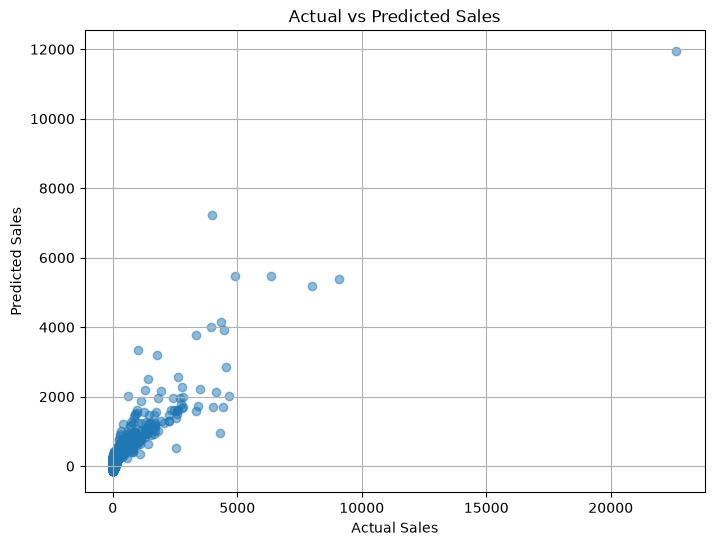

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    sales_pred,
    alpha=0.5
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.grid(True)

plt.show()

## Business Insight

Compare predicted values with actual sales to evaluate model accuracy.

# Random Forest Model

In [11]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [12]:
rf_pred = rf.predict(X_test)

In [13]:
print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 :", r2_score(y_test, rf_pred))

MAE : 21.952107829914958
RMSE : 344.0895722999655
R2 : 0.7995635659898894


In [14]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(10)

Sales Per Unit              0.565127
Profit                      0.213316
Quantity                    0.099885
Customer Lifetime Sales     0.047099
Order Value Category        0.044434
Customer Lifetime Profit    0.007117
Profit Margin               0.003357
Row ID                      0.001828
Order ID                    0.001513
Ship Date                   0.001433
dtype: float64

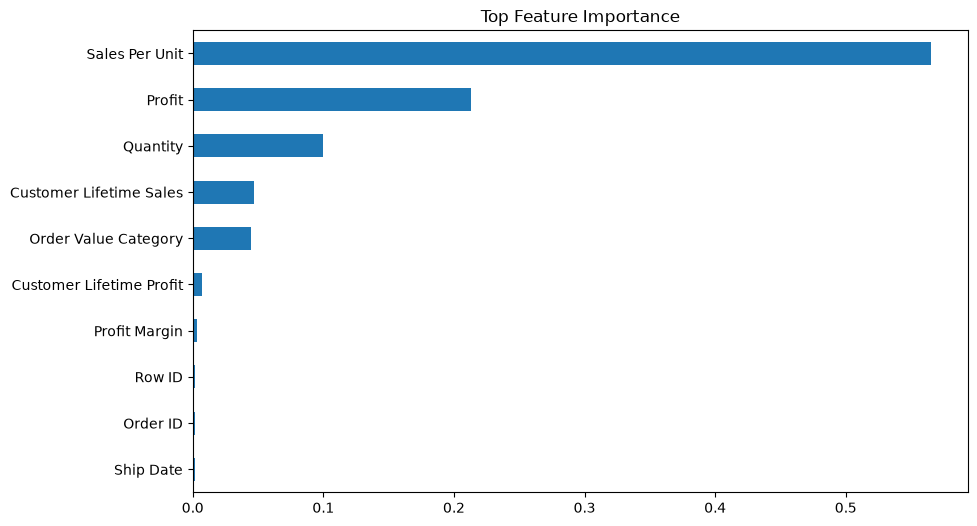

In [15]:
importance.sort_values().tail(10).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Feature Importance")

plt.show()

## Business Insight

Feature importance identifies which variables most strongly influence sales prediction.

# Profit Prediction

In [16]:
X = df_ml.drop(columns=["Profit"])

y = df_ml["Profit"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
rf_profit = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_profit.fit(
    X_train,
    y_train
)

profit_pred = rf_profit.predict(
    X_test
)

In [19]:
print("Profit Prediction")

print("MAE :", mean_absolute_error(y_test, profit_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, profit_pred)))

print("R2 :", r2_score(y_test, profit_pred))

Profit Prediction
MAE : 12.987532931465733
RMSE : 192.4411470271849
R2 : 0.236186469849624


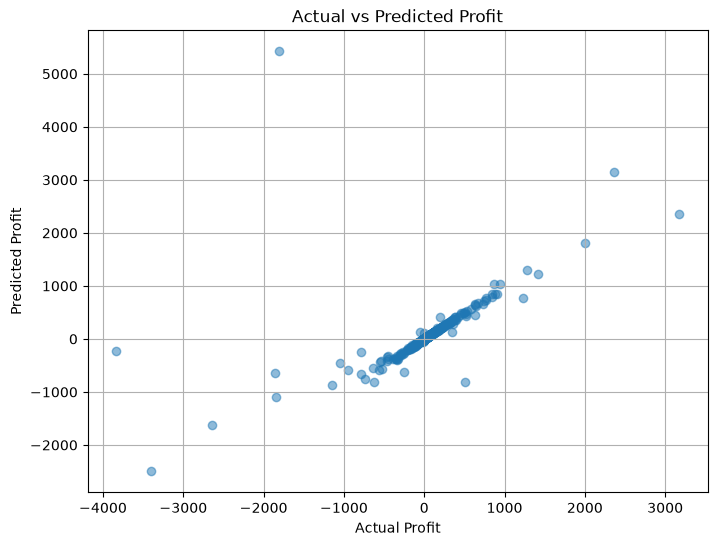

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    profit_pred,
    alpha=0.5
)

plt.xlabel("Actual Profit")

plt.ylabel("Predicted Profit")

plt.title("Actual vs Predicted Profit")

plt.grid(True)

plt.show()

# Save Models

In [21]:
joblib.dump(
    rf,
    "../models/sales_prediction_model.pkl"
)

joblib.dump(
    rf_profit,
    "../models/profit_prediction_model.pkl"
)

print("Models saved successfully!")

Models saved successfully!


# Notebook Summary

## Tasks Completed

- Loaded feature engineered dataset
- Encoded categorical variables
- Built Linear Regression model
- Built Random Forest model
- Predicted Sales
- Predicted Profit
- Evaluated models using MAE, RMSE and R²
- Visualized prediction accuracy
- Identified important features
- Saved trained machine learning models

## Business Recommendations

- Use the Sales Prediction model to forecast future revenue.
- Use the Profit Prediction model to estimate profitability before making business decisions.
- Focus on the most influential features to improve business performance.